In [1]:
import kagglehub
import os
import re
import random
import numpy as np
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [2]:
# Download dataset
path = kagglehub.dataset_download("ouaraskhelilrafik/iris-images")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ouaraskhelilrafik/iris-images


In [3]:
# Config
CFG = {
    "data_root":    f"{path}/iris_images",
    "img_size":     224,
    "embed_dim":    128,
    "margin":       1.0,        
    "batch_size":   32,
    "epochs":       20,
    "lr":           1e-4,
    "seed":         42,
    "train_ratio":  0.75,
    "val_ratio":    0.10,
    "pairs_per_id": 4,          
    "device":       "cuda" if torch.cuda.is_available() else "cpu",
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

In [4]:
def parse_dataset(data_root: str) -> dict[str, list[str]]:
    identity_images = defaultdict(list)
    data_root = Path(data_root)

    for img_path in sorted(data_root.rglob("*.png")):
        filename = img_path.stem
        m = re.match(r"(\d+)([LR])", filename)
        if m:
            person_id, side = m.group(1), m.group(2)
            identity = f"{person_id}{side}"
        else:
            parts = img_path.parts
            folder   = parts[-3] if len(parts) >= 3 else "unknown"
            side_dir = parts[-2] if len(parts) >= 2 else "unknown"
            identity = f"{folder}_{side_dir[0].upper()}"

        identity_images[identity].append(str(img_path))

    identity_images = {k: v for k, v in identity_images.items() if len(v) >= 2}
    print(f"Found {len(identity_images)} identities, {sum(len(v) for v in identity_images.values())} images total.")
    return identity_images

In [5]:
def split_identities(identity_images: dict, cfg: dict) -> tuple[dict, dict, dict]:
    ids = list(identity_images.keys())
    random.shuffle(ids)

    n        = len(ids)
    n_train  = int(n * cfg["train_ratio"])
    n_val    = int(n * cfg["val_ratio"])

    train_ids = ids[:n_train]
    val_ids   = ids[n_train : n_train + n_val]
    test_ids  = ids[n_train + n_val :]

    train_data = {k: identity_images[k] for k in train_ids}
    val_data   = {k: identity_images[k] for k in val_ids}
    test_data  = {k: identity_images[k] for k in test_ids}

    print(f"Split — train: {len(train_data)} ids | val: {len(val_data)} ids | test: {len(test_data)} ids")
    return train_data, val_data, test_data

In [6]:
def generate_pairs(identity_images: dict, pairs_per_id: int = 4) -> list[tuple]:
    all_ids   = list(identity_images.keys())
    pos_pairs = []
    neg_pairs = []

    for identity, images in identity_images.items():
        combos = list(combinations(images, 2))
        sampled = random.sample(combos, min(pairs_per_id, len(combos)))
        for img1, img2 in sampled:
            pos_pairs.append((img1, img2, 1))

    n_neg = len(pos_pairs)
    while len(neg_pairs) < n_neg:
        id1, id2 = random.sample(all_ids, 2)
        img1 = random.choice(identity_images[id1])
        img2 = random.choice(identity_images[id2])
        neg_pairs.append((img1, img2, 0))

    pairs = pos_pairs + neg_pairs
    random.shuffle(pairs)
    print(f"  Generated {len(pos_pairs)} positive + {len(neg_pairs)} negative pairs")
    return pairs

In [7]:
def get_transforms(img_size: int, train: bool) -> transforms.Compose:
    base = [
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),
    ]
    if train:
        aug = [transforms.RandomRotation(degrees=10), transforms.ColorJitter(brightness=0.3)]
    else:
        aug = []
    post = [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5,  0.5,  0.5]),
    ]
    return transforms.Compose(base + aug + post)

In [8]:
class IrisPairDataset(Dataset):

    def __init__(self, pairs: list[tuple], transform: transforms.Compose):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        path1, path2, label = self.pairs[idx]
        img1 = self.transform(Image.open(path1).convert("L"))
        img2 = self.transform(Image.open(path2).convert("L"))
        return img1, img2, torch.tensor(label, dtype=torch.float32)

print("done")

done


In [9]:
class EmbeddingNet(nn.Module):

    def __init__(self, embed_dim: int = 128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )
        self.backbone = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.backbone(x), p=2, dim=1)

In [10]:
class SiameseNet(nn.Module):

    def __init__(self, embed_dim: int = 128):
        super().__init__()
        self.embedding_net = EmbeddingNet(embed_dim)

    def forward(self, img1: torch.Tensor, img2: torch.Tensor):
        return self.embedding_net(img1), self.embedding_net(img2)

In [11]:
class ContrastiveLoss(nn.Module):

    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1: torch.Tensor, emb2: torch.Tensor, label: torch.Tensor) -> torch.Tensor:
        dist = F.pairwise_distance(emb1, emb2)
        pos_loss = label * dist.pow(2)
        neg_loss = (1 - label) * F.relu(self.margin - dist).pow(2)
        return (pos_loss + neg_loss).mean()

In [12]:
def compute_accuracy(emb1, emb2, labels, threshold: float = 0.5) -> float:
    dist = F.pairwise_distance(emb1, emb2).detach().cpu()
    return ((dist < threshold).float() == labels.cpu()).float().mean().item()

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    for img1, img2, labels in loader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        optimizer.zero_grad()
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc  += compute_accuracy(emb1, emb2, labels)
    return total_loss / len(loader), total_acc / len(loader)

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    for img1, img2, labels in loader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, labels)
        total_loss += loss.item()
        total_acc  += compute_accuracy(emb1, emb2, labels)
    return total_loss / len(loader), total_acc / len(loader)

In [15]:
def train(model, train_loader, val_loader, cfg):
    device = cfg["device"]
    criterion = ContrastiveLoss(margin=cfg["margin"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_loss)

        for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc]): history[k].append(v)

        print(f"Epoch {epoch:3d}/{cfg['epochs']}  train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {vl_loss:.4f} acc {vl_acc:.3f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "best_siamese.pth")
            print(f"  ✓ saved best model (val_loss={vl_loss:.4f})")

    return history

print("done")

done


In [16]:
@torch.no_grad()
def get_distances_and_labels(model, loader, device):
    model.eval()
    all_dists, all_labels = [], []
    for img1, img2, labels in loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = model(img1, img2)
        dists = F.pairwise_distance(emb1, emb2).cpu().numpy()
        all_dists.extend(dists)
        all_labels.extend(labels.numpy())
    return np.array(all_dists), np.array(all_labels)

In [17]:
def find_best_threshold(distances, labels) -> float:
    fpr, tpr, thresholds = roc_curve(labels, -distances)
    fnr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer_threshold = -thresholds[eer_idx]
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    print(f"EER = {eer:.3f} at threshold = {eer_threshold:.4f}")
    return float(eer_threshold)

In [18]:
def plot_distance_distributions(distances, labels, threshold: float = None):
    same_dists, diff_dists = distances[labels == 1], distances[labels == 0]
    plt.figure(figsize=(8, 4))
    plt.hist(same_dists, bins=40, alpha=0.6, color="steelblue", label="Same identity")
    plt.hist(diff_dists, bins=40, alpha=0.6, color="tomato", label="Different identity")
    if threshold is not None:
        plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"Threshold = {threshold:.3f}")
    plt.xlabel("Euclidean distance"); plt.ylabel("Count"); plt.title("Distance distribution — test set")
    plt.legend(); plt.tight_layout(); plt.show()

In [19]:
def plot_training_history(history: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"], label="Val")
    ax1.set_title("Contrastive loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"], label="Val")
    ax2.set_title("Accuracy (threshold=0.5)"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

In [20]:
class IrisVerifier:

    def __init__(self, checkpoint_path: str, threshold: float, cfg: dict = CFG):
        self.threshold = threshold
        self.device    = cfg["device"]
        self.transform = get_transforms(cfg["img_size"], train=False)
        self.model = SiameseNet(embed_dim=cfg["embed_dim"]).to(self.device)
        self.model.load_state_dict(torch.load(checkpoint_path, map_location=self.device))
        self.model.eval()

    @torch.no_grad()
    def get_embedding(self, image_path: str) -> torch.Tensor:
        img = self.transform(Image.open(image_path).convert("L")).unsqueeze(0).to(self.device)
        return self.model.embedding_net(img)

    @torch.no_grad()
    def verify(self, path1: str, path2: str) -> dict:
        emb1, emb2 = self.get_embedding(path1), self.get_embedding(path2)
        dist = F.pairwise_distance(emb1, emb2).item()
        match = dist < self.threshold
        return {"match": match, "distance": round(dist, 4), "threshold": self.threshold, "verdict": "MATCH ✓" if match else "NO MATCH ✗"}

print("done")

done


In [21]:
# Execution Pipeline
device = CFG["device"]
print(f"Using device: {device}\n")

identity_images = parse_dataset(CFG["data_root"])
train_data, val_data, test_data = split_identities(identity_images, CFG)

Using device: cuda

Found 128 identities, 384 images total.
Split — train: 96 ids | val: 12 ids | test: 20 ids


In [22]:
print("\nGenerating pairs...")
train_pairs = generate_pairs(train_data, CFG["pairs_per_id"])
val_pairs   = generate_pairs(val_data,   CFG["pairs_per_id"])
test_pairs  = generate_pairs(test_data,  CFG["pairs_per_id"])


Generating pairs...
  Generated 288 positive + 288 negative pairs
  Generated 36 positive + 36 negative pairs
  Generated 60 positive + 60 negative pairs


In [23]:
train_loader = DataLoader(IrisPairDataset(train_pairs, get_transforms(CFG["img_size"], True)),  batch_size=CFG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(IrisPairDataset(val_pairs,   get_transforms(CFG["img_size"], False)), batch_size=CFG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(IrisPairDataset(test_pairs,  get_transforms(CFG["img_size"], False)), batch_size=CFG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

In [24]:
model = SiameseNet(embed_dim=CFG["embed_dim"]).to(device)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s] 



Model parameters: 11,242,432



Training for 20 epochs...

Epoch   1/20  train loss 0.2513 acc 0.661 | val loss 0.0490 acc 0.969
  ✓ saved best model (val_loss=0.0490)
Epoch   2/20  train loss 0.0849 acc 0.913 | val loss 0.0385 acc 0.979
  ✓ saved best model (val_loss=0.0385)
Epoch   3/20  train loss 0.0658 acc 0.953 | val loss 0.0330 acc 0.990
  ✓ saved best model (val_loss=0.0330)
Epoch   4/20  train loss 0.0577 acc 0.969 | val loss 0.0308 acc 0.990
  ✓ saved best model (val_loss=0.0308)
Epoch   5/20  train loss 0.0515 acc 0.967 | val loss 0.0307 acc 0.979
  ✓ saved best model (val_loss=0.0307)
Epoch   6/20  train loss 0.0436 acc 0.984 | val loss 0.0305 acc 0.990
  ✓ saved best model (val_loss=0.0305)
Epoch   7/20  train loss 0.0415 acc 0.979 | val loss 0.0278 acc 0.979
  ✓ saved best model (val_loss=0.0278)
Epoch   8/20  train loss 0.0385 acc 0.986 | val loss 0.0300 acc 0.979
Epoch   9/20  train loss 0.0306 acc 0.998 | val loss 0.0260 acc 0.979
  ✓ saved best model (val_loss=0.0260)
Epoch  10/20  train loss 0.033

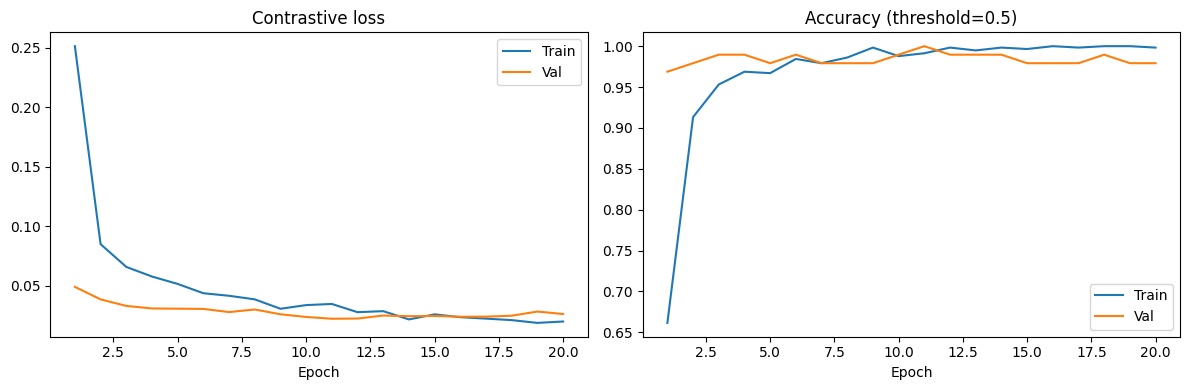

In [25]:
print(f"\nTraining for {CFG['epochs']} epochs...\n")
history = train(model, train_loader, val_loader, CFG)
plot_training_history(history)

In [26]:
print("\nEvaluating on test set...")
model.load_state_dict(torch.load("best_siamese.pth", map_location=device))

val_dists, val_labels = get_distances_and_labels(model, val_loader, device)
threshold = find_best_threshold(val_dists, val_labels)

test_dists, test_labels = get_distances_and_labels(model, test_loader, device)
accuracy = ((test_dists < threshold).astype(float) == test_labels).mean()
print(f"Test accuracy at EER threshold: {accuracy:.3f}")


Evaluating on test set...
EER = 0.000 at threshold = 0.4420
Test accuracy at EER threshold: 0.950


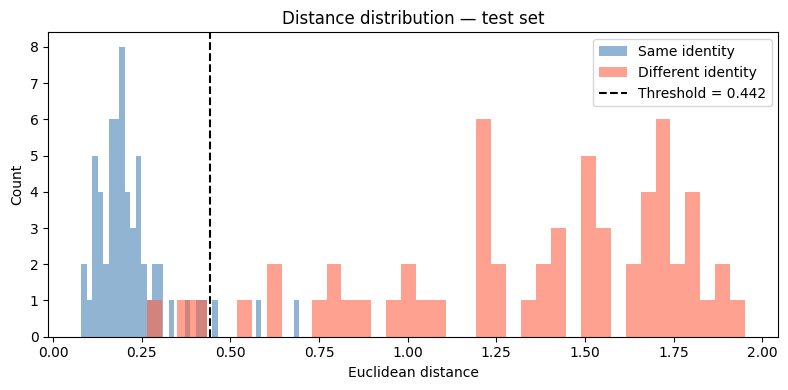

In [27]:
plot_distance_distributions(test_dists, test_labels, threshold)

In [28]:
# Demo Inference
sample_images = test_data[list(test_data.keys())[0]]
if len(sample_images) >= 2:
    verifier = IrisVerifier("best_siamese.pth", threshold=threshold)
    print(f"\nDemo inference:")
    print(f"  {verifier.verify(sample_images[0], sample_images[1])}")

print("\nDone.")


Demo inference:
  {'match': True, 'distance': 0.214, 'threshold': 0.44204047322273254, 'verdict': 'MATCH ✓'}

Done.


Confusion Matrix:
 [[57  3]
 [ 3 57]]
✅ Accuracy from Confusion Matrix: 0.950



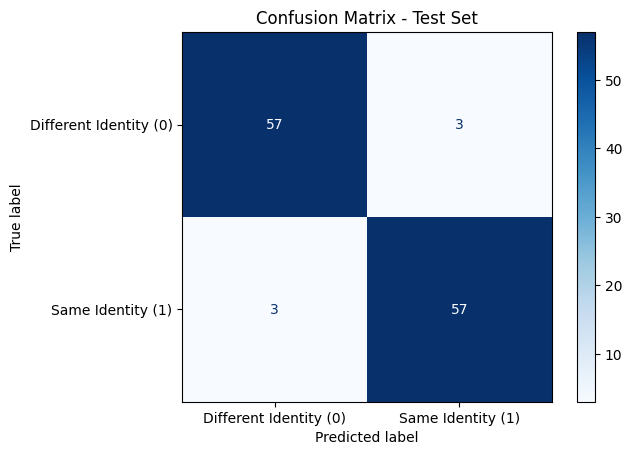

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate predictions based on the threshold found earlier
test_preds = (test_dists < threshold).astype(int)

# 2. Compute Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:\n", cm)

# 3. Verify accuracy matches your previous result
cm_accuracy = cm.diagonal().sum() / cm.sum()
print(f"✅ Accuracy from Confusion Matrix: {cm_accuracy:.3f}\n")

# 4. Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Different Identity (0)", "Same Identity (1)"])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.show()

## test


In [30]:
# ── Sanity-check inference (Robust & Deterministic) ───────────────────────
import random, re
from pathlib import Path
from PIL import Image

# 🔒 Fixed seed guarantees the SAME random pick every time you run the notebook
random.seed(42)

In [31]:
def run_verify(verifier, path1, path2, label):
    result = verifier.verify(path1, path2)
    status = "PASS" if (result["match"] == (label == "MATCH")) else "FAIL"
    print(f"  [{status}] Expected {label:8s} | {result['verdict']:12s} | dist={result['distance']:.4f}")
    print(f"         img1: {Path(path1).name}")
    print(f"         img2: {Path(path2).name}")
    print()

In [32]:
all_images = parse_dataset(CFG["data_root"])
person_ids = set()
for key in all_images:
    m = re.match(r"(\d+)([LR])", key)
    if m: person_ids.add(m.group(1))

# Sort first, then sample -> Guaranteed reproducible across all environments
bilateral = sorted([pid for pid in person_ids if f"{pid}L" in all_images and f"{pid}R" in all_images])
assert len(bilateral) >= 2, "Not enough people with both L/R images."

# Picks different people than the sorted order, avoiding the 001 edge-case
pid1, pid2 = random.sample(bilateral, 2)

imgs_1L = all_images[f"{pid1}L"]
imgs_1R = all_images[f"{pid1}R"]
imgs_2L = all_images[f"{pid2}L"]

Found 128 identities, 384 images total.


In [33]:
verifier = IrisVerifier("best_siamese.pth", threshold=threshold)

print("=" * 60)
print(f"Scenario 1 — same person {pid1}, same iris → MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_1L[1], "MATCH")

print("=" * 60)
print(f"Scenario 2 — same person {pid1}, left vs right iris → NO MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_1R[0], "NO MATCH")

print("=" * 60)
print(f"Scenario 3 — different people {pid1} vs {pid2} → NO MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_2L[0], "NO MATCH")

Scenario 1 — same person 015, same iris → MATCH
  [PASS] Expected MATCH    | MATCH ✓      | dist=0.0902
         img1: 015L_1.png
         img2: 015L_2.png

Scenario 2 — same person 015, left vs right iris → NO MATCH
  [PASS] Expected NO MATCH | NO MATCH ✗   | dist=0.8717
         img1: 015L_1.png
         img2: 015R_1.png

Scenario 3 — different people 015 vs 004 → NO MATCH
  [PASS] Expected NO MATCH | NO MATCH ✗   | dist=0.5232
         img1: 015L_1.png
         img2: 004L_1.png



## test real data


In [34]:
# ── Custom photo test: your own iris images ──────────────────────────────────
from pathlib import Path
import torch.nn.functional as F
from PIL import Image

CUSTOM_ROOT = Path("/kaggle/input/datasets/alaekh/qqqqqqqq/test_user")

In [35]:
def run_verify_custom(verifier, path1, path2, expected_label):
    result = verifier.verify(str(path1), str(path2))
    passed = (result["match"] == (expected_label == "MATCH"))
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] Expected {expected_label:8s} | {result['verdict']:12s} | dist={result['distance']:.4f}")
    print(f"         img1: {path1.name}")
    print(f"         img2: {path2.name}")
    print()

In [36]:
verifier = IrisVerifier("best_siamese.pth", threshold=threshold)

print("=" * 60)
print("Test 1 — al1.jpg vs al2.jpg (same person, same iris) → MATCH")
print("=" * 60)
run_verify_custom(verifier,
    CUSTOM_ROOT / "al1.jpg",
    CUSTOM_ROOT / "al2.jpg",
    "MATCH")

print("=" * 60)
print("Test 2 — ak1.jpg vs al1.jpg (different people) → NO MATCH")
print("=" * 60)
run_verify_custom(verifier,
    CUSTOM_ROOT / "ak1.jpg",
    CUSTOM_ROOT / "al1.jpg",
    "NO MATCH")

Test 1 — al1.jpg vs al2.jpg (same person, same iris) → MATCH
  [PASS] Expected MATCH    | MATCH ✓      | dist=0.2125
         img1: al1.jpg
         img2: al2.jpg

Test 2 — ak1.jpg vs al1.jpg (different people) → NO MATCH
  [PASS] Expected NO MATCH | NO MATCH ✗   | dist=0.8126
         img1: ak1.jpg
         img2: al1.jpg

